#### **Data Preprocessing**

In [2]:
import pandas as pd
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from facenet_pytorch import MTCNN


/mnt/c/Users/rodri/4º ano/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In this first preprocessing stage, the objective is to create a new version of the dataset containing only the facial region of each image. Since this project focuses on deepfake detection, using face crops helps reduce background noise and forces the model to focus on facial details, where synthetic artifacts are more likely to appear.

#### **Face Crop**

In [ ]:
df = pd.read_csv("../data/metadata.csv")


In [4]:
# INITIALIZE FACE DETECTOR

device = "cuda" if torch.cuda.is_available() else "cpu"

mtcnn = MTCNN(
    image_size=224,
    margin=20,
    post_process=False,
    device=device
)


In [5]:
# FACE CROPPING FUNCTION

def crop_face_from_original(image, margin=40, output_size=(224, 224)):
    """
    Detects the main face using MTCNN and crops it directly
    from the original image while preserving normal colors.
    """

    boxes, probs = mtcnn.detect(image)

    if boxes is None:
        return None

    best_idx = probs.argmax()

    x1, y1, x2, y2 = boxes[best_idx]

    w, h = image.size

    x1 = max(int(x1) - margin, 0)
    y1 = max(int(y1) - margin, 0)

    x2 = min(int(x2) + margin, w)
    y2 = min(int(y2) + margin, h)

    face_img = image.crop((x1, y1, x2, y2))

    face_img = face_img.resize(output_size)

    return face_img

In [ ]:
# CREATE FACE CROPPED DATASET

OUTPUT_DIR = "../data/face_crop_final_1"

sample_df = df

saved = 0
failed = 0

for idx, row in tqdm(sample_df.iterrows(), total=len(sample_df)):

    try:

        img_path = "../" + row["filepath"]

        image = Image.open(img_path).convert("RGB")

        face_img = crop_face_from_original(image)

        if face_img is None:
            failed += 1
            continue

        relative_path = row["filepath"].replace("data/", "")

        save_path = os.path.join(
            OUTPUT_DIR,
            relative_path
        )

        os.makedirs(
            os.path.dirname(save_path),
            exist_ok=True
        )

        face_img.save(save_path)

        saved += 1

    except Exception:
        failed += 1


print("\nFace crop process finished.")
print("Saved images:", saved)
print("Failed images:", failed)

  1%|          | 728/120000 [03:37<9:54:53,  3.34it/s] 


The face-cropped dataset was created by detecting the main face in each image using MTCNN. Instead of saving the tensor produced directly by MTCNN, the bounding box was used to crop the face from the original image, preserving the original colors and visual quality. The cropped images were saved in a new folder called face_crop_final, while maintaining the same folder structure as the original dataset.

#### **IMAGES WHERE FACE CROP FAILED**

Some images could not be processed because the face detector failed to detect a valid facial region. This may happen due to low image quality, unusual poses, occlusions, drawings, or images where the face is not clearly visible.

These samples were removed from the final preprocessed dataset to ensure that all images used for training contain a valid face crop.

In [6]:
df["face_crop_filepath"] = df["filepath"].apply(
    lambda x: x.replace("data/", "data/face_crop_final/")
)

df["face_crop_exists"] = df["face_crop_filepath"].apply(
    lambda x: os.path.exists("../" + x)
)

print("Total images in metadata:", len(df))
print("Face crops found:", df["face_crop_exists"].sum())
print("Missing face crops:", (~df["face_crop_exists"]).sum())

df_face = df[df["face_crop_exists"]].reset_index(drop=True)

print("Final dataset size:", len(df_face))

Total images in metadata: 120000
Face crops found: 114876
Missing face crops: 5124
Final dataset size: 114876


In [7]:
missing_faces = df[~df["face_crop_exists"]]

print("Total missing face crops:", len(missing_faces))

missing_faces["source_type"].value_counts()

Total missing face crops: 5124


source_type
text2image    1464
inpainting    1444
insight       1369
wiki           847
Name: count, dtype: int64

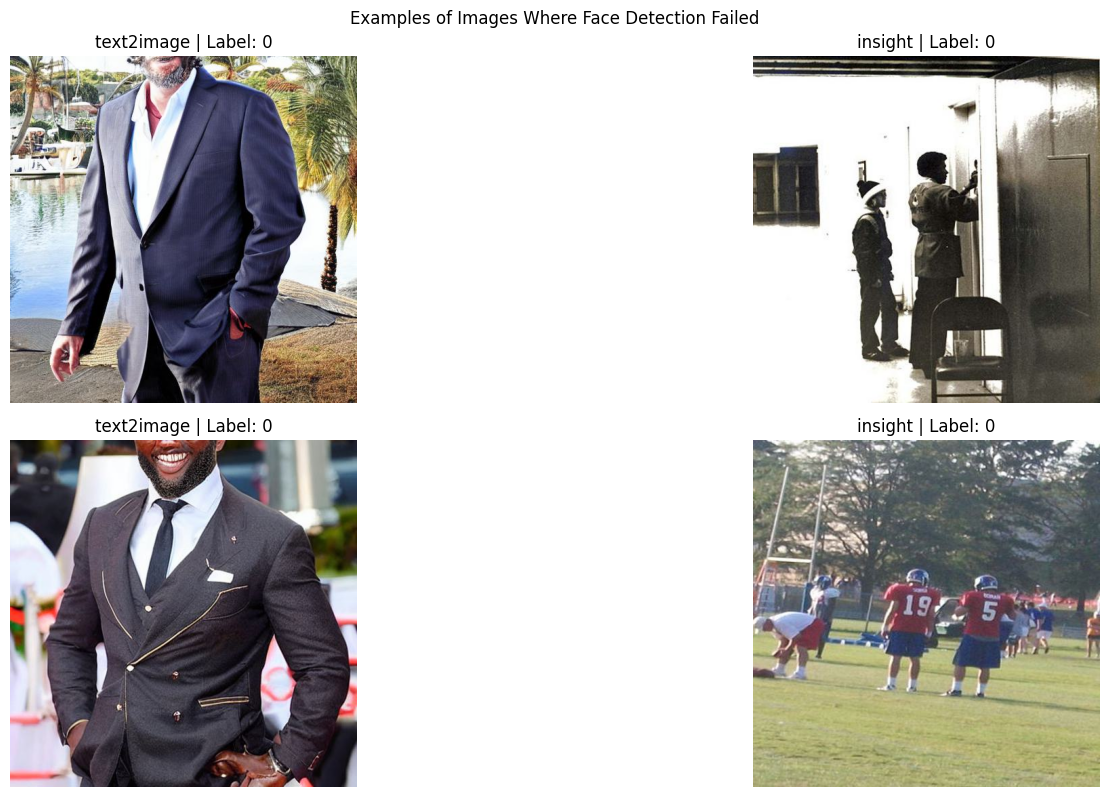

In [12]:
missing_faces = df[~df["face_crop_exists"]]

sample_missing = missing_faces.sample(4).reset_index(drop=True)

plt.figure(figsize=(15, 12))

for i in range(len(sample_missing)):

    row = sample_missing.iloc[i]

    img_path = "../" + row["filepath"]

    try:
        img = Image.open(img_path).convert("RGB")

        plt.subplot(3, 2, i + 1)

        plt.imshow(img)

        plt.title(
            f"{row['source_type']} | Label: {row['label']}"
        )

        plt.axis("off")

    except:
        continue

plt.suptitle("Examples of Images Where Face Detection Failed")

plt.tight_layout()

plt.show()

In [9]:
df_face.groupby("split")["label"].value_counts(normalize=True) * 100

split  label
test   0        74.606676
       1        25.393324
train  0        74.640637
       1        25.359363
val    0        74.551680
       1        25.448320
Name: proportion, dtype: float64

In [10]:
train_df = df_face[df_face["split"] == "train"].reset_index(drop=True)
val_df = df_face[df_face["split"] == "val"].reset_index(drop=True)
test_df = df_face[df_face["split"] == "test"].reset_index(drop=True)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 80420
Validation: 17231
Test: 17225


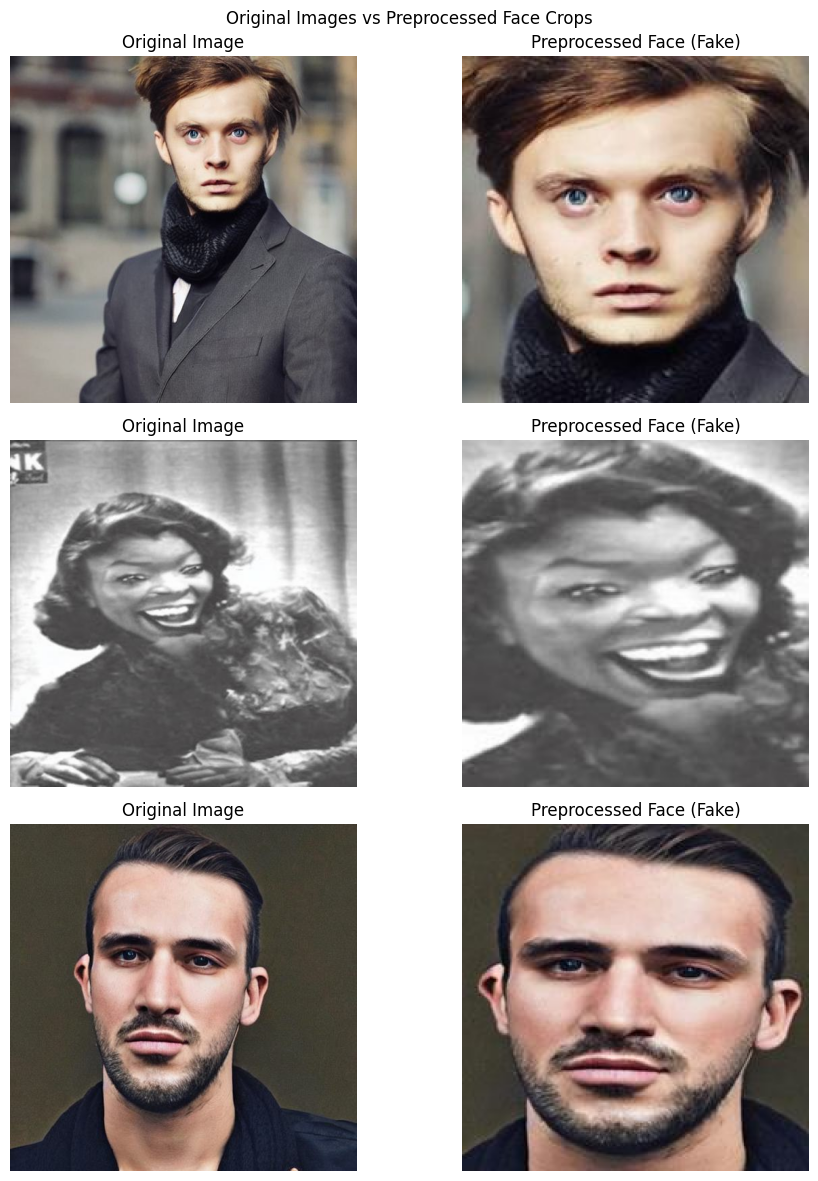

In [11]:
sample_df = train_df.sample(3).reset_index(drop=True)

plt.figure(figsize=(10, 12))

for i in range(3):

    row = sample_df.iloc[i]

    original_path = "../" + row["filepath"]

    original_img = Image.open(original_path).convert("RGB")

    plt.subplot(3, 2, i*2 + 1)

    plt.imshow(original_img)

    plt.title("Original Image")

    plt.axis("off")

    processed_path = "../" + row["face_crop_filepath"]

    processed_img = Image.open(processed_path).convert("RGB")

    label_name = "Real" if row["label"] == 1 else "Fake"

    plt.subplot(3, 2, i*2 + 2)

    plt.imshow(processed_img)

    plt.title(f"Preprocessed Face ({label_name})")

    plt.axis("off")


plt.suptitle("Original Images vs Preprocessed Face Crops")

plt.tight_layout()

plt.show()

#### **Conclusion**

This preprocessing pipeline prepared the dataset for deepfake detection by focusing exclusively on facial information. Using MTCNN, the main face was detected and cropped from each image, reducing unnecessary background information and allowing the models to focus on facial features that are more relevant for classification.

Some images could not be processed successfully due to failed face detection, usually caused by partial visibility, extreme poses, occlusion, or low image quality. These samples were removed from the final dataset.

After face extraction, all cropped images were resized to a fixed resolution of 224×224 pixels and normalized to ensure consistency across the dataset. Finally, the processed images were organized into training, validation, and testing subsets, making the dataset ready for deep learning model training and evaluation.